In [1]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 103.7 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 12.2 MB/s eta 0:00:00
Note: you may need to restart 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import mlflow, mlflow.sklearn
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import joblib
import gc

In [3]:
headers = [
    # --- Network Identity (Usually dropped before modeling) ---
    'src_ip',          # Source IP address
    'src_port',        # Source port number
    'dst_ip',          # Destination IP address
    'dst_port',        # Destination port number

    # --- Protocol & Session Characteristics ---
    'protocol',        # Protocol type (TCP, UDP, etc.)
    'conn_state',      # Connection state (CON, FIN, etc.)
    'duration',        # Total session duration (in seconds)

    # --- Data Volume & Packets ---
    'src_to_dst_bytes', # Number of bytes from source to destination
    'dst_to_src_bytes', # Number of bytes from destination to source
    'src_ttl',          # Source Time-to-Live (TTL)
    'dst_ttl',          # Destination Time-to-Live (TTL)
    'src_loss',         # Packet loss from source
    'dst_loss',         # Packet loss from destination

    # --- Speed & Load Statistics ---
    'service_type',     # Service type (dns, http, smtp, etc.)
    'src_load_bps',     # Bits per second from source (Source Load)
    'dst_load_bps',     # Bits per second from destination (Dest Load)
    'src_packet_count', # Total packet count from source
    'dst_packet_count', # Total packet count from destination

    # --- TCP Technical Details ---
    'src_window_adv',   # Source window advertisement
    'dst_window_adv',   # Destination window advertisement
    'src_tcp_seq',      # Source TCP sequence number
    'dst_tcp_seq',      # Destination TCP sequence number
    'src_mean_packet_size', # Mean packet size from source
    'dst_mean_packet_size', # Mean packet size from destination

    # --- Content & Time ---
    'http_trans_depth', # HTTP transaction depth
    'http_res_body_len',# HTTP response body length
    'src_jitter',       # Source packet arrival time variation (jitter)
    'dst_jitter',       # Destination packet arrival time variation (jitter)
    'start_time',       # Start time timestamp
    'last_time',        # End time timestamp
    'src_inter_packet_time', # Inter-packet time from source (mms)
    'dst_inter_packet_time', # Inter-packet time from destination (mms)

    # --- Latency Metrics (Highly Critical for Forensics) ---
    'tcp_rtt',          # Total Round Trip Time (synack + ackdat)
    'tcp_synack_time',  # Time between SYN and SYN-ACK (connection setup)
    'tcp_ackdat_time',  # Time between SYN-ACK and ACK (data confirmation)

    # --- Contextual & Security Features ---
    'is_same_ip_port',  # Whether source & destination IP and Port are the same (1/0)
    'ct_state_ttl',     # Connection count based on state and TTL
    'ct_http_method',   # Count of HTTP method usage (GET/POST)
    'is_ftp_login',     # Whether this is an FTP login session (1/0)
    'ct_ftp_command',   # Count of commands in FTP session
    'ct_src_srv_count', # Count of connections for the same service from source
    'ct_dst_srv_count', # Count of connections for the same service to destination
    'ct_dst_ltm_count', # Count of connections to the same destination (last 100)
    'ct_src_ltm_count', # Count of connections from the same source (last 100)
    'ct_src_dport_count', # Count of connections to the same destination port from source
    'ct_dst_sport_count', # Count of connections from the same source port to destination
    'ct_src_dst_count', # Count of connections between the same source and destination

    # --- Classification ---
    'attack_category',  # Attack category name (if any)
    'label'             # 0 = Normal, 1 = Attack
]

In [4]:
url = "https://github.com/FatiBuuloloo/Dynamic_Thresholding_-Network_Traffic-/releases/download/dataset/UNSW-NB15_1.csv"
data1 = pd.read_csv(url, names=headers, low_memory=False)
print(f"""
Columns : {data1.columns}
Shape : {data1.shape}
""")


Columns : Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'conn_state',
       'duration', 'src_to_dst_bytes', 'dst_to_src_bytes', 'src_ttl',
       'dst_ttl', 'src_loss', 'dst_loss', 'service_type', 'src_load_bps',
       'dst_load_bps', 'src_packet_count', 'dst_packet_count',
       'src_window_adv', 'dst_window_adv', 'src_tcp_seq', 'dst_tcp_seq',
       'src_mean_packet_size', 'dst_mean_packet_size', 'http_trans_depth',
       'http_res_body_len', 'src_jitter', 'dst_jitter', 'start_time',
       'last_time', 'src_inter_packet_time', 'dst_inter_packet_time',
       'tcp_rtt', 'tcp_synack_time', 'tcp_ackdat_time', 'is_same_ip_port',
       'ct_state_ttl', 'ct_http_method', 'is_ftp_login', 'ct_ftp_command',
       'ct_src_srv_count', 'ct_dst_srv_count', 'ct_dst_ltm_count',
       'ct_src_ltm_count', 'ct_src_dport_count', 'ct_dst_sport_count',
       'ct_src_dst_count', 'attack_category', 'label'],
      dtype='object')
Shape : (700001, 49)



In [5]:
url = "https://github.com/FatiBuuloloo/Dynamic_Thresholding_-Network_Traffic-/releases/download/dataset/UNSW-NB15_2.csv"
data2 = pd.read_csv(url, names=headers, low_memory=False)
print(f"""
Columns : {data2.columns}
Shape : {data2.shape}
""")


Columns : Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'conn_state',
       'duration', 'src_to_dst_bytes', 'dst_to_src_bytes', 'src_ttl',
       'dst_ttl', 'src_loss', 'dst_loss', 'service_type', 'src_load_bps',
       'dst_load_bps', 'src_packet_count', 'dst_packet_count',
       'src_window_adv', 'dst_window_adv', 'src_tcp_seq', 'dst_tcp_seq',
       'src_mean_packet_size', 'dst_mean_packet_size', 'http_trans_depth',
       'http_res_body_len', 'src_jitter', 'dst_jitter', 'start_time',
       'last_time', 'src_inter_packet_time', 'dst_inter_packet_time',
       'tcp_rtt', 'tcp_synack_time', 'tcp_ackdat_time', 'is_same_ip_port',
       'ct_state_ttl', 'ct_http_method', 'is_ftp_login', 'ct_ftp_command',
       'ct_src_srv_count', 'ct_dst_srv_count', 'ct_dst_ltm_count',
       'ct_src_ltm_count', 'ct_src_dport_count', 'ct_dst_sport_count',
       'ct_src_dst_count', 'attack_category', 'label'],
      dtype='object')
Shape : (700001, 49)



In [6]:
url = "https://github.com/FatiBuuloloo/Dynamic_Thresholding_-Network_Traffic-/releases/download/dataset/UNSW-NB15_3.csv"
data3 = pd.read_csv(url, names=headers, low_memory=False)
print(f"""
Columns : {data3.columns}
Shape : {data3.shape}
""")


Columns : Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'conn_state',
       'duration', 'src_to_dst_bytes', 'dst_to_src_bytes', 'src_ttl',
       'dst_ttl', 'src_loss', 'dst_loss', 'service_type', 'src_load_bps',
       'dst_load_bps', 'src_packet_count', 'dst_packet_count',
       'src_window_adv', 'dst_window_adv', 'src_tcp_seq', 'dst_tcp_seq',
       'src_mean_packet_size', 'dst_mean_packet_size', 'http_trans_depth',
       'http_res_body_len', 'src_jitter', 'dst_jitter', 'start_time',
       'last_time', 'src_inter_packet_time', 'dst_inter_packet_time',
       'tcp_rtt', 'tcp_synack_time', 'tcp_ackdat_time', 'is_same_ip_port',
       'ct_state_ttl', 'ct_http_method', 'is_ftp_login', 'ct_ftp_command',
       'ct_src_srv_count', 'ct_dst_srv_count', 'ct_dst_ltm_count',
       'ct_src_ltm_count', 'ct_src_dport_count', 'ct_dst_sport_count',
       'ct_src_dst_count', 'attack_category', 'label'],
      dtype='object')
Shape : (700001, 49)



In [7]:
url = "https://github.com/FatiBuuloloo/Dynamic_Thresholding_-Network_Traffic-/releases/download/dataset/UNSW-NB15_4.csv"
data4 = pd.read_csv(url, names=headers, low_memory=False)
print(f"""
Columns : {data4.columns}
Shape : {data4.shape}
""")


Columns : Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'conn_state',
       'duration', 'src_to_dst_bytes', 'dst_to_src_bytes', 'src_ttl',
       'dst_ttl', 'src_loss', 'dst_loss', 'service_type', 'src_load_bps',
       'dst_load_bps', 'src_packet_count', 'dst_packet_count',
       'src_window_adv', 'dst_window_adv', 'src_tcp_seq', 'dst_tcp_seq',
       'src_mean_packet_size', 'dst_mean_packet_size', 'http_trans_depth',
       'http_res_body_len', 'src_jitter', 'dst_jitter', 'start_time',
       'last_time', 'src_inter_packet_time', 'dst_inter_packet_time',
       'tcp_rtt', 'tcp_synack_time', 'tcp_ackdat_time', 'is_same_ip_port',
       'ct_state_ttl', 'ct_http_method', 'is_ftp_login', 'ct_ftp_command',
       'ct_src_srv_count', 'ct_dst_srv_count', 'ct_dst_ltm_count',
       'ct_src_ltm_count', 'ct_src_dport_count', 'ct_dst_sport_count',
       'ct_src_dst_count', 'attack_category', 'label'],
      dtype='object')
Shape : (440044, 49)



In [8]:
missing_info = pd.concat([
    data1.isna().sum(),
    data2.isna().sum(),
    data3.isna().sum(),
    data4.isna().sum()
], axis=1)
missing_info.columns = ['data1', 'data2', 'data3', 'data4']
missing_info

,data1,data2,data3,data4
src_ip,0,0,0,0
src_port,0,0,0,0
dst_ip,0,0,0,0
dst_port,0,0,0,0
protocol,0,0,0,0
conn_state,0,0,0,0
duration,0,0,0,0
src_to_dst_bytes,0,0,0,0
dst_to_src_bytes,0,0,0,0
src_ttl,0,0,0,0


In [9]:
print(f"total missing in attack_category: {missing_info.loc['attack_category',:].sum()}")

total missing in attack_category: 2218764


In [10]:
list_data = [data1, data2, data3, data4]
df_combined = pd.concat(list_data, axis=0, ignore_index=True)
print("Shape:", df_combined.shape)
df_combined.head()

Shape: (2540047, 49)


,src_ip,src_port,dst_ip,dst_port,protocol,conn_state,duration,src_to_dst_bytes,dst_to_src_bytes,src_ttl,...,ct_ftp_command,ct_src_srv_count,ct_dst_srv_count,ct_dst_ltm_count,ct_src_ltm_count,ct_src_dport_count,ct_dst_sport_count,ct_src_dst_count,attack_category,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


In [11]:
df_combined["label"].value_counts()

label
0    2218764
1     321283
Name: count, dtype: int64

In [12]:
df_combined[(df_combined['attack_category'].isna()) & (df_combined['label']==0)]

,src_ip,src_port,dst_ip,dst_port,protocol,conn_state,duration,src_to_dst_bytes,dst_to_src_bytes,src_ttl,...,ct_ftp_command,ct_src_srv_count,ct_dst_srv_count,ct_dst_ltm_count,ct_src_ltm_count,ct_src_dport_count,ct_dst_sport_count,ct_src_dst_count,attack_category,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540041,59.166.0.1,38606,149.171.126.9,80,tcp,CON,0.564998,14106,772406,31,...,,2,1,4,2,2,2,2,NaN,0
2540042,59.166.0.5,33094,149.171.126.7,43433,tcp,FIN,0.087306,320,1828,31,...,,1,2,3,3,1,1,3,NaN,0
2540043,59.166.0.7,20848,149.171.126.4,21,tcp,CON,0.365058,456,346,31,...,2,2,2,2,2,2,2,2,NaN,0
2540044,59.166.0.3,21511,149.171.126.9,21,tcp,CON,6.335154,1802,2088,31,...,2,2,2,4,2,2,2,2,NaN,0


## **Observation:**
### During the initial data profiling, a total of **2,218,764 missing values (NaN)** were identified within the `attack_category` column.

### Imputing Missing Values in attack_category as 'Normal

In [13]:
df_combined['attack_category'] = df_combined['attack_category'].apply(lambda x: "Normal" if pd.isna(x) else x)
df_combined.head()

,src_ip,src_port,dst_ip,dst_port,protocol,conn_state,duration,src_to_dst_bytes,dst_to_src_bytes,src_ttl,...,ct_ftp_command,ct_src_srv_count,ct_dst_srv_count,ct_dst_ltm_count,ct_src_ltm_count,ct_src_dport_count,ct_dst_sport_count,ct_src_dst_count,attack_category,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,Normal,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,Normal,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,Normal,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,Normal,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,Normal,0


In [14]:
for item in df_combined.select_dtypes(include=['object']).columns:
    print(f"{item} : {df_combined[item].unique()}\n")

src_ip : ['59.166.0.0' '59.166.0.6' '59.166.0.5' '59.166.0.3' '10.40.182.3'
 '59.166.0.7' '10.40.170.2' '59.166.0.1' '59.166.0.2' '59.166.0.4'
 '175.45.176.3' '175.45.176.2' '175.45.176.0' '59.166.0.8' '59.166.0.9'
 '175.45.176.1' '10.40.182.1' '10.40.85.1' '192.168.241.243' '10.40.85.30'
 '149.171.126.16' '149.171.126.2' '149.171.126.11' '149.171.126.4'
 '149.171.126.5' '149.171.126.17' '149.171.126.19' '149.171.126.9'
 '149.171.126.8' '149.171.126.7' '149.171.126.15' '149.171.126.6'
 '149.171.126.0' '149.171.126.1' '149.171.126.3' '149.171.126.13'
 '149.171.126.12' '149.171.126.10' '149.171.126.18' '127.0.0.1'
 '149.171.126.14' '10.40.85.10' '10.40.182.6']

src_port : ['1390' '33661' '1464' ... 533 933 706]

dst_ip : ['149.171.126.6' '149.171.126.9' '149.171.126.7' '149.171.126.5'
 '149.171.126.0' '149.171.126.4' '10.40.182.3' '10.40.170.2'
 '149.171.126.18' '149.171.126.16' '149.171.126.8' '149.171.126.2'
 '149.171.126.1' '149.171.126.10' '149.171.126.3' '149.171.126.15'
 '149.171.1

### Data Cleaning and Port Standardization

This section handles anomalous string entries and missing values across key network transaction columns to ensure strict mathematical compatibility for model training.

**1. Identification of Port Anomalyes**
* Performed profiling on `src_port` and `dst_port` to catch non-numeric tokens such as hyphens or hexadecimal notation.
* Quantified the volume of corrupted data points requiring structural parsing.

**2. Custom Port Type-Casting and Range Validation**
* Implemented a robust extraction logic via the `clean_port` utility function.
* Stripped metadata Anomalyes, converted valid hexadecimal inputs (0x) into standard integer format, and enforced valid TCP/UDP boundaries between 0 and 65535.
* Classified all completely broken or missing port artifacts safely into a uniform marker value of `-1`.

**3. Specific Protocol Counter Refinement**
* Restructured the `ct_ftp_command` column by treating invalid or empty values as zero events and casting the final outputs into hard integers.
* Mitigated remaining blank observations inside `ct_http_method` and `is_ftp_login` by replacing null variables with a clear baseline of `0`.

**Current Status:** The composite framework is now entirely free of null parameters across these operational dimensions and successfully prepared for numerical optimization.

In [15]:
non_numeric_dst = df_combined[pd.to_numeric(df_combined['dst_port'], errors='coerce').isna()]
print(non_numeric_dst['dst_port'].unique())
print(pd.to_numeric(df_combined['dst_port'], errors='coerce').isna().sum())

['0xc0a8' '-' '0x20205321' '0xcc09']
304


In [16]:
non_numeric_src = df_combined[pd.to_numeric(df_combined['src_port'], errors='coerce').isna()]
print(non_numeric_dst['src_port'].unique())
print(pd.to_numeric(df_combined['src_port'], errors='coerce').isna().sum())

['49320' '0x000b' '768' '256' '0x000c' '4352' '-' '0' '3328' 2048]
8


In [17]:
def clean_port(value):
    try:
        v = str(value).strip()
        if v == '-' or v == '':
            return -1
        if v.startswith('0x'):
            dec_val = int(v, 16)
            return dec_val if dec_val <= 65535 else -1
        final_val = int(float(v))
        return final_val if 0 <= final_val <= 65535 else -1
    except:
        return -1
df_combined['src_port'] = df_combined['src_port'].apply(clean_port)
df_combined['dst_port'] = df_combined['dst_port'].apply(clean_port)
df_combined['ct_ftp_command'] = pd.to_numeric(df_combined['ct_ftp_command'], errors='coerce')
df_combined['ct_ftp_command'] = df_combined['ct_ftp_command'].fillna(0).astype(int)
df_combined['ct_ftp_command'].unique()

array([0, 1, 6, 2, 4, 8, 5, 3])

In [18]:
df_combined[['ct_http_method','is_ftp_login']] = df_combined[['ct_http_method','is_ftp_login']].fillna(0)
df_combined.isna().sum()

src_ip                   0
src_port                 0
dst_ip                   0
dst_port                 0
protocol                 0
conn_state               0
duration                 0
src_to_dst_bytes         0
dst_to_src_bytes         0
src_ttl                  0
dst_ttl                  0
src_loss                 0
dst_loss                 0
service_type             0
src_load_bps             0
dst_load_bps             0
src_packet_count         0
dst_packet_count         0
src_window_adv           0
dst_window_adv           0
src_tcp_seq              0
dst_tcp_seq              0
src_mean_packet_size     0
dst_mean_packet_size     0
http_trans_depth         0
http_res_body_len        0
src_jitter               0
dst_jitter               0
start_time               0
last_time                0
src_inter_packet_time    0
dst_inter_packet_time    0
tcp_rtt                  0
tcp_synack_time          0
tcp_ackdat_time          0
is_same_ip_port          0
ct_state_ttl             0
c

In [19]:
for item in df_combined.columns:
    print(df_combined[item].value_counts(normalize=True)*100)
    print()

src_ip
59.166.0.4         7.793517
59.166.0.1         7.782533
59.166.0.5         7.780407
59.166.0.2         7.777415
59.166.0.0         7.776549
59.166.0.3         7.714542
59.166.0.9         7.487539
59.166.0.6         7.457303
59.166.0.8         7.454232
59.166.0.7         7.443130
175.45.176.1       5.039198
175.45.176.3       4.672079
175.45.176.0       3.267617
149.171.126.18     3.215689
149.171.126.15     1.767015
149.171.126.14     1.615994
175.45.176.2       1.260843
149.171.126.10     1.195450
149.171.126.12     0.633138
10.40.85.1         0.158186
10.40.182.1        0.156847
10.40.182.6        0.137478
10.40.85.30        0.084172
10.40.182.3        0.082872
10.40.170.2        0.082439
10.40.85.10        0.031220
149.171.126.5      0.013346
149.171.126.1      0.012244
149.171.126.3      0.012244
149.171.126.4      0.011811
149.171.126.6      0.011732
149.171.126.2      0.011614
149.171.126.8      0.011456
149.171.126.9      0.011220
149.171.126.7      0.010630
149.171.126.0

#### Replacing "-" character in **"service_type"** columns

In [20]:
df_combined['service_type'] = df_combined['service_type'].replace('-', 'unknown')

### Feature Binarization for Zero-Inflated Columns

Based on the data profiling results, the columns `ct_state_ttl`, `ct_http_method`, `is_ftp_login`, and `ct_ftp_command` are heavily zero-inflated, meaning that over 85% of their records contain a value of exactly 0. 

To handle this extreme skewness and improve the performance of our Autoencoder model, we transform these continuous and multi-valued variables into binary indicators using a threshold of greater than 0. This changes the model's task from learning heavily skewed frequency counts to detecting the presence or absence of specific network behaviors.

**Transformation Logic:**
* Value == 0 -> 0 (Absence of activity)
* Value >  0 -> 1 (Presence of activity)

The original columns are then dropped to prevent redundant information in our training pipeline.

In [21]:
to_biner_columns = ["ct_state_ttl", "ct_http_method", "is_ftp_login", "ct_ftp_command"]
df_combined['has_state_ttl'] = (df_combined['ct_state_ttl'] > 0).astype(int)
df_combined['is_http_request'] = (df_combined['ct_http_method'] > 0).astype(int)
df_combined['has_ftp_login_attempt'] = (df_combined['is_ftp_login'] > 0).astype(int)
df_combined['has_ftp_command'] = (df_combined['ct_ftp_command'] > 0).astype(int)
df_combined.drop(columns=to_biner_columns,axis=1,inplace=True)

In [22]:
categorical_cols = df_combined.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    df_combined[col] = df_combined[col].astype(str).str.lstrip()

### Checking Data Distribution

#### **1**
### feature : **'src_to_dst_bytes','dst_to_src_bytes','src_loss','dst_loss','src_packet_count','dst_packet_count','src_mean_packet_size','dst_mean_packet_size','http_res_body_len'**

In [23]:
feature_list1 = ['src_to_dst_bytes','dst_to_src_bytes','src_loss','dst_loss','src_packet_count','dst_packet_count','src_mean_packet_size','dst_mean_packet_size','http_res_body_len']
df_combined[feature_list1].describe()

,src_to_dst_bytes,dst_to_src_bytes,src_loss,dst_loss,src_packet_count,dst_packet_count,src_mean_packet_size,dst_mean_packet_size,http_res_body_len
count,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06
mean,4.339600e+03,3.642759e+04,5.163921e+00,1.632944e+01,3.328884e+01,4.272664e+01,1.242536e+02,2.766719e+02,4.242118e+03
std,5.640599e+04,1.610960e+05,2.251707e+01,5.659474e+01,7.628388e+01,1.215020e+02,1.519162e+02,3.356166e+02,4.750053e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+02,1.780000e+02,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,6.000000e+01,6.900000e+01,0.000000e+00
50%,1.470000e+03,1.820000e+03,3.000000e+00,4.000000e+00,1.200000e+01,1.200000e+01,7.300000e+01,8.900000e+01,0.000000e+00
75%,3.182000e+03,1.489400e+04,7.000000e+00,1.400000e+01,4.400000e+01,4.200000e+01,1.320000e+02,5.650000e+02,0.000000e+00
max,1.435577e+07,1.465753e+07,5.319000e+03,5.507000e+03,1.064600e+04,1.101800e+04,1.504000e+03,1.500000e+03,6.558056e+06


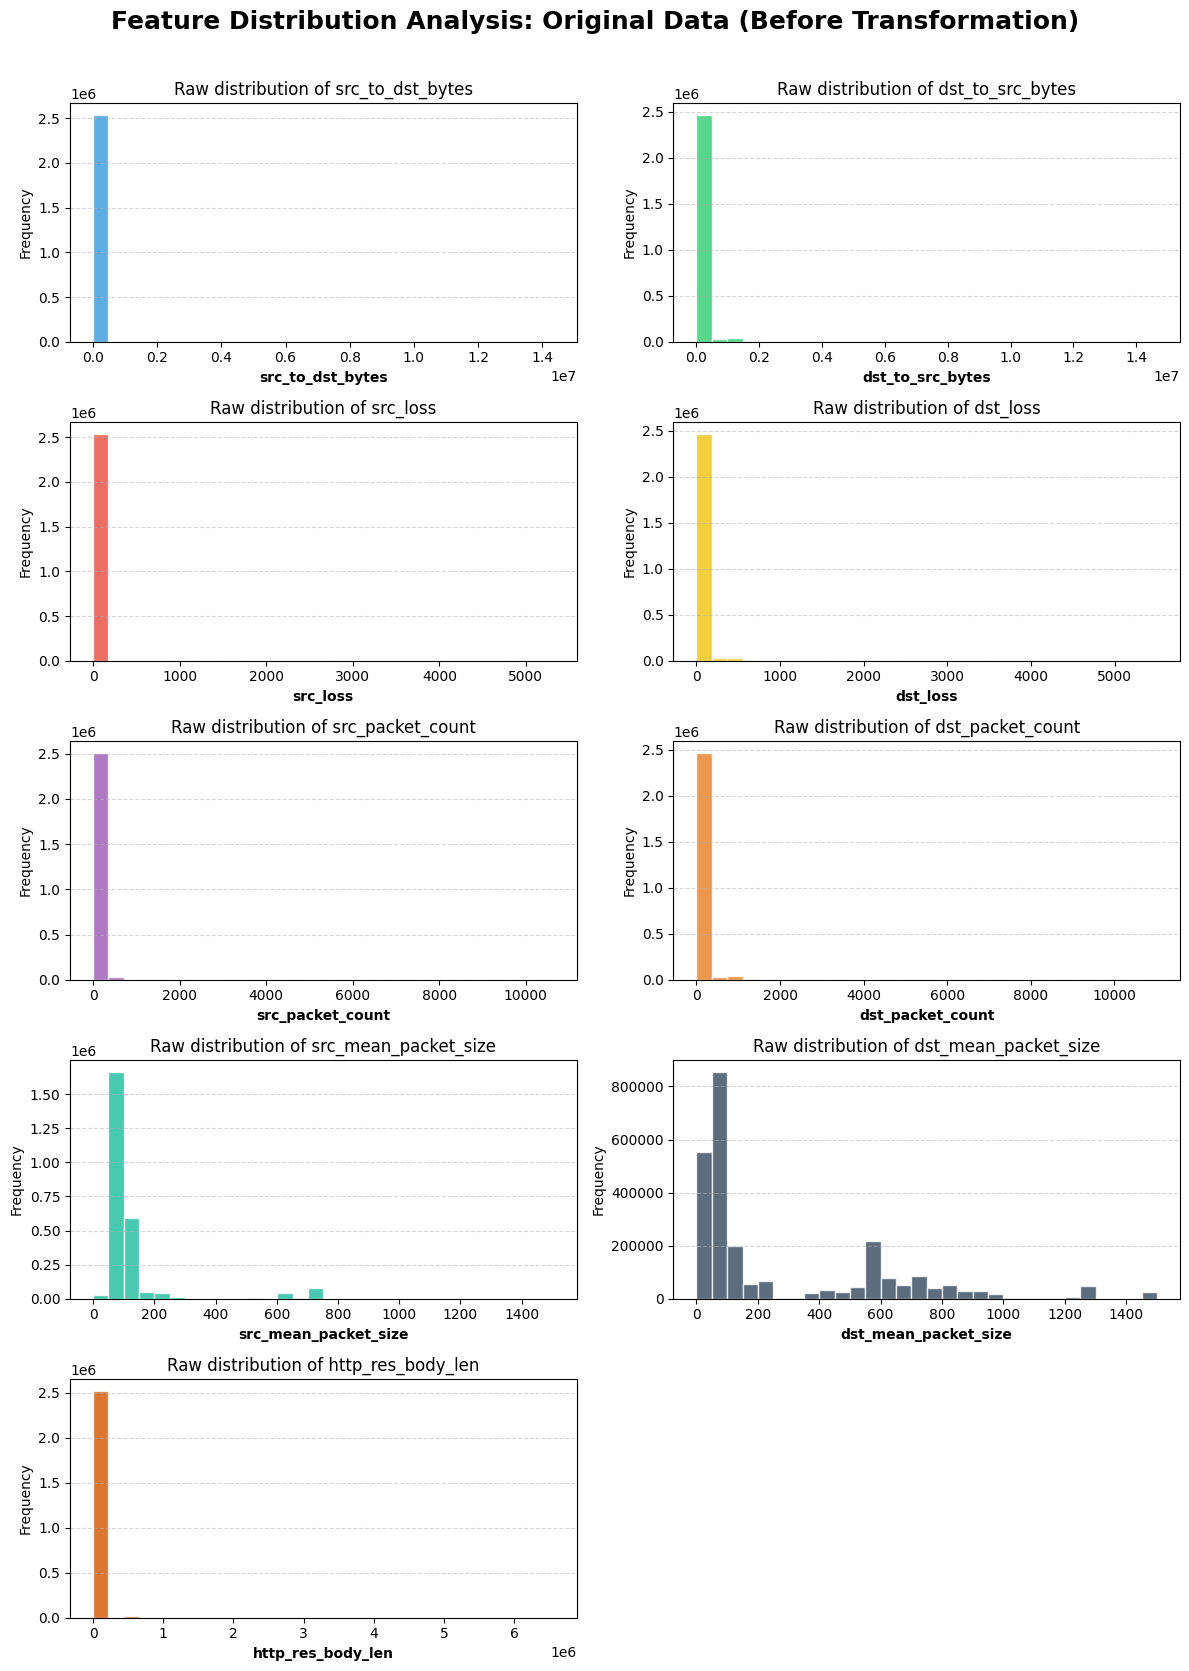

In [24]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 17))
fig.suptitle('Feature Distribution Analysis: Original Data (Before Transformation)', fontsize=18, fontweight='bold')
axes = axes.flatten()

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6', 
          '#e67e22', '#1abc9c', '#34495e', '#d35400']

for i, feature in enumerate(feature_list1):
    axes[i].hist(df_combined[feature].dropna(), bins=30, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Raw distribution of {feature}', fontsize=12)
    axes[i].set_xlabel(feature, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

axes[-1].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

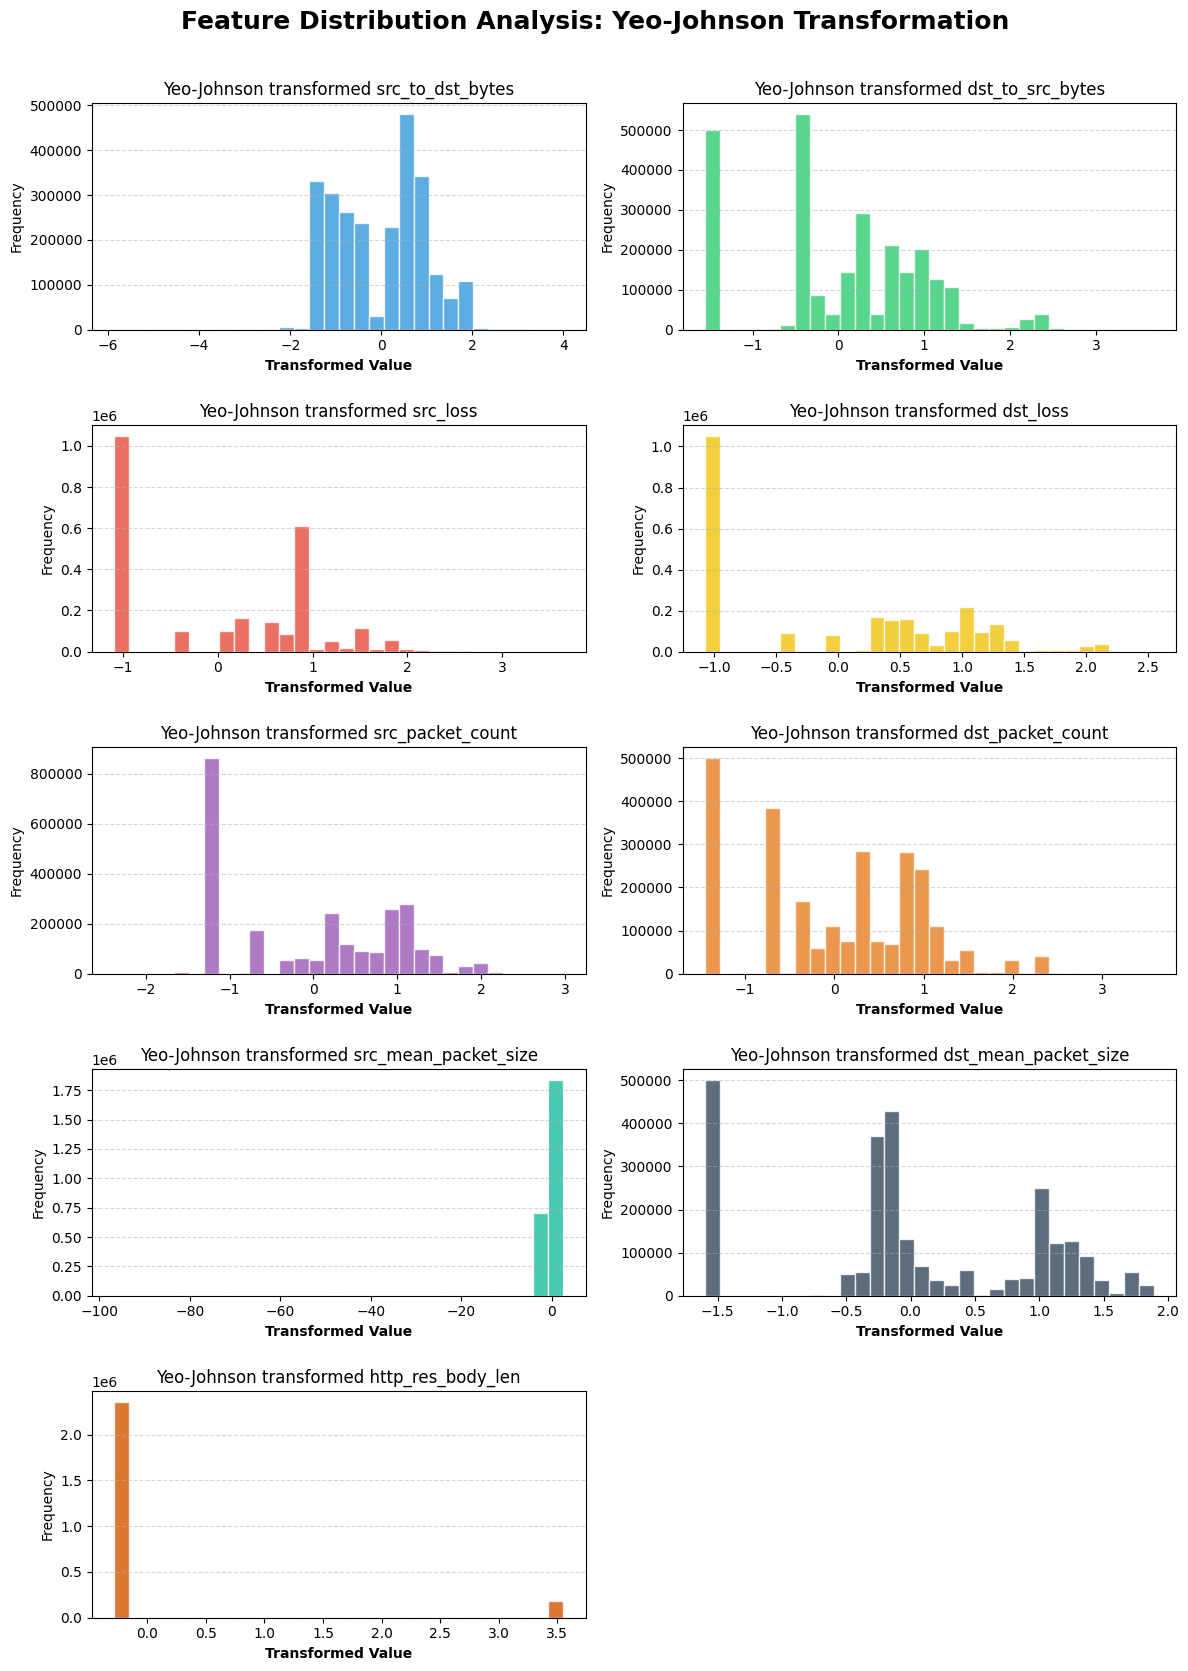

41096

In [25]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson', standardize=True)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 17))
fig.suptitle('Feature Distribution Analysis: Yeo-Johnson Transformation', fontsize=18, fontweight='bold')
axes = axes.flatten()

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6', 
          '#e67e22', '#1abc9c', '#34495e', '#d35400']

for i, feature in enumerate(feature_list1):
    data_clean = df_combined[feature].dropna().values.reshape(-1, 1)
    transformed_data = pt.fit_transform(data_clean)
    
    axes[i].hist(transformed_data, bins=30, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Yeo-Johnson transformed {feature}', fontsize=12)
    axes[i].set_xlabel('Transformed Value', fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

axes[-1].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
del data_clean
del pt
del transformed_data
gc.collect()

### **2**
### feature : **'src_ttl','dst_ttl','src_window_adv','dst_window_adv'**


In [26]:
feature_list2 = ['src_ttl','dst_ttl','src_window_adv','dst_window_adv']
df_combined[feature_list2].describe()

,src_ttl,dst_ttl,src_window_adv,dst_window_adv
count,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06
mean,6.278197e+01,3.076681e+01,1.500887e+02,1.497459e+02
std,7.462277e+01,4.285089e+01,1.254824e+02,1.255438e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.100000e+01,2.900000e+01,0.000000e+00,0.000000e+00
50%,3.100000e+01,2.900000e+01,2.550000e+02,2.550000e+02
75%,3.100000e+01,2.900000e+01,2.550000e+02,2.550000e+02
max,2.550000e+02,2.540000e+02,2.550000e+02,2.550000e+02


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_combined2 = df_combined[feature_list2]
df_combined2 = scaler.fit_transform(df_combined2)
df_combined2 = pd.DataFrame(df_combined2, columns=feature_list2)
df_combined2.describe()

,src_ttl,dst_ttl,src_window_adv,dst_window_adv
count,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06
mean,2.462038e-01,1.211292e-01,5.885833e-01,5.872388e-01
std,2.926383e-01,1.687043e-01,4.920879e-01,4.923288e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.215686e-01,1.141732e-01,0.000000e+00,0.000000e+00
50%,1.215686e-01,1.141732e-01,1.000000e+00,1.000000e+00
75%,1.215686e-01,1.141732e-01,1.000000e+00,1.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


#### **3**
### feature : **'http_trans_depth','ct_src_srv_count','ct_dst_srv_count','ct_dst_ltm_count','ct_src_ltm_count','ct_src_dport_count','ct_dst_sport_count','ct_src_dst_count'**

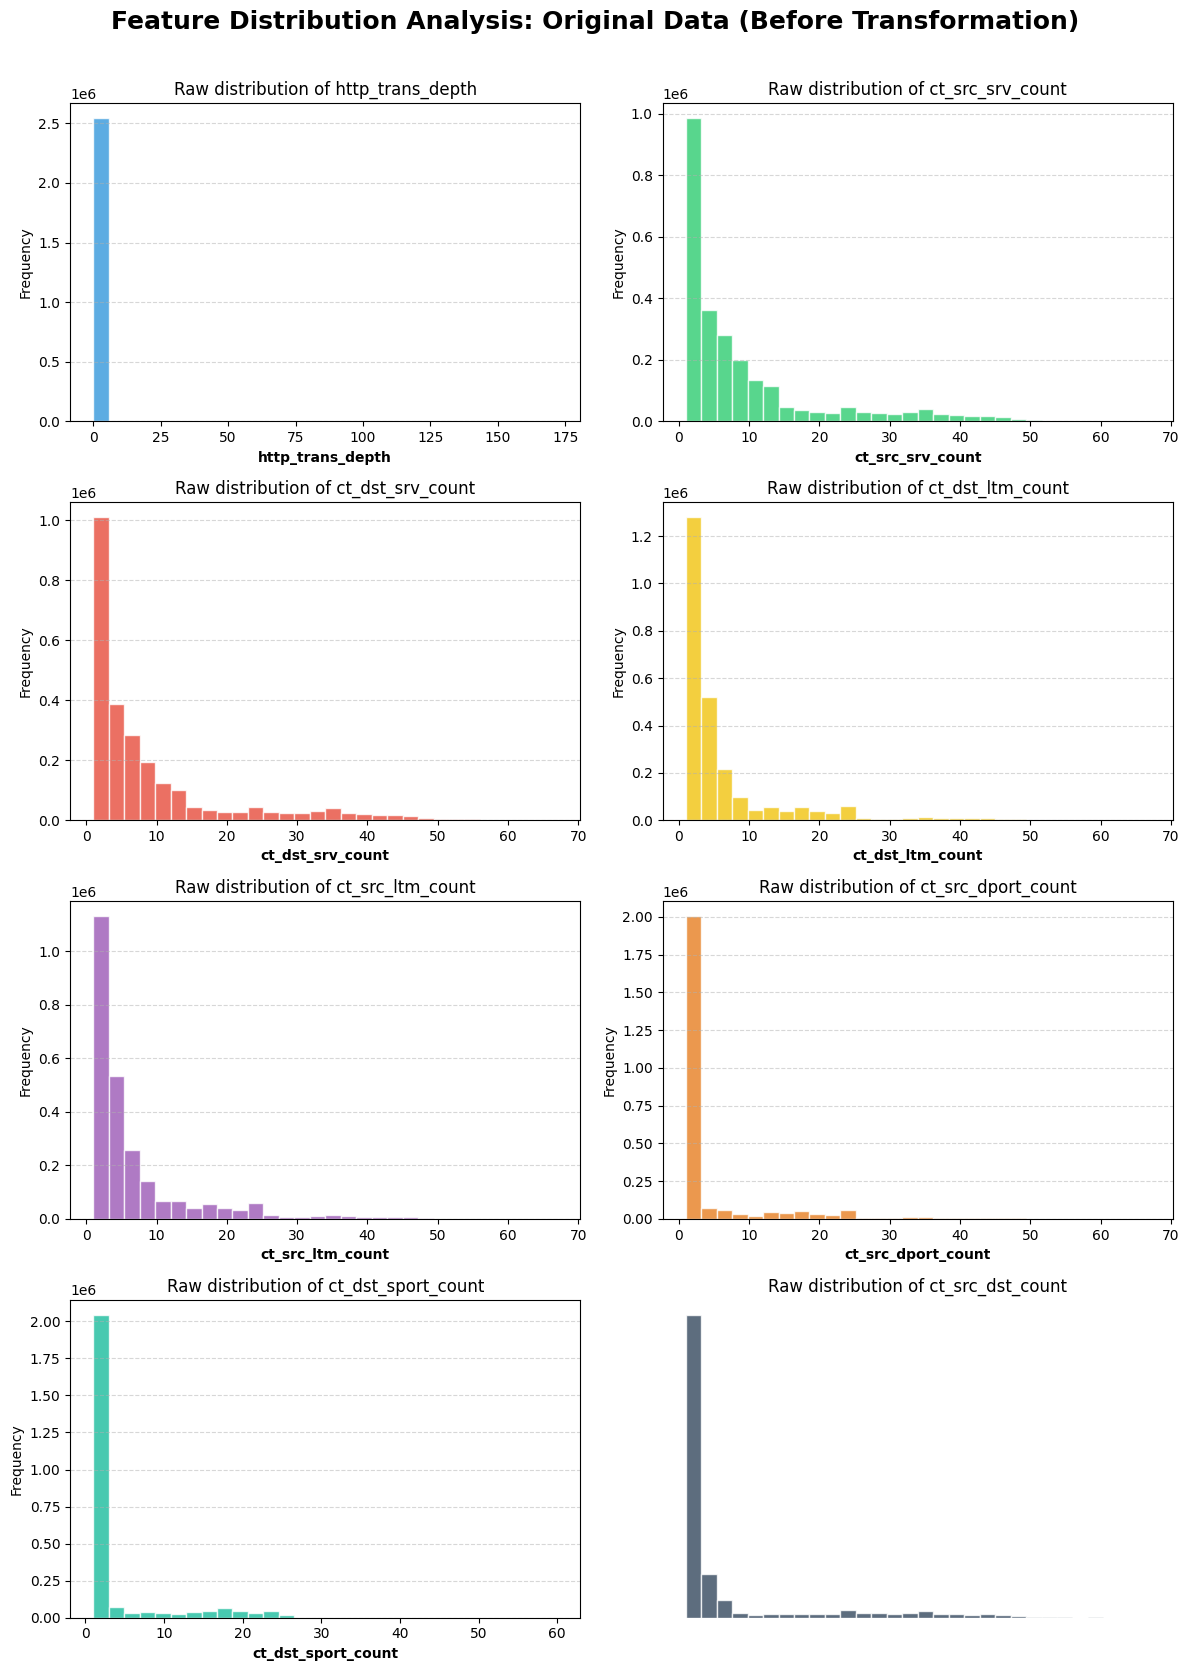

In [28]:
feature_list3 = ['http_trans_depth','ct_src_srv_count','ct_dst_srv_count','ct_dst_ltm_count','ct_src_ltm_count','ct_src_dport_count','ct_dst_sport_count','ct_src_dst_count']
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 17))
fig.suptitle('Feature Distribution Analysis: Original Data (Before Transformation)', fontsize=18, fontweight='bold')
axes = axes.flatten()

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6', 
          '#e67e22', '#1abc9c', '#34495e', '#d35400']

for i, feature in enumerate(feature_list3):
    axes[i].hist(df_combined[feature].dropna(), bins=30, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Raw distribution of {feature}', fontsize=12)
    axes[i].set_xlabel(feature, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

axes[-1].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

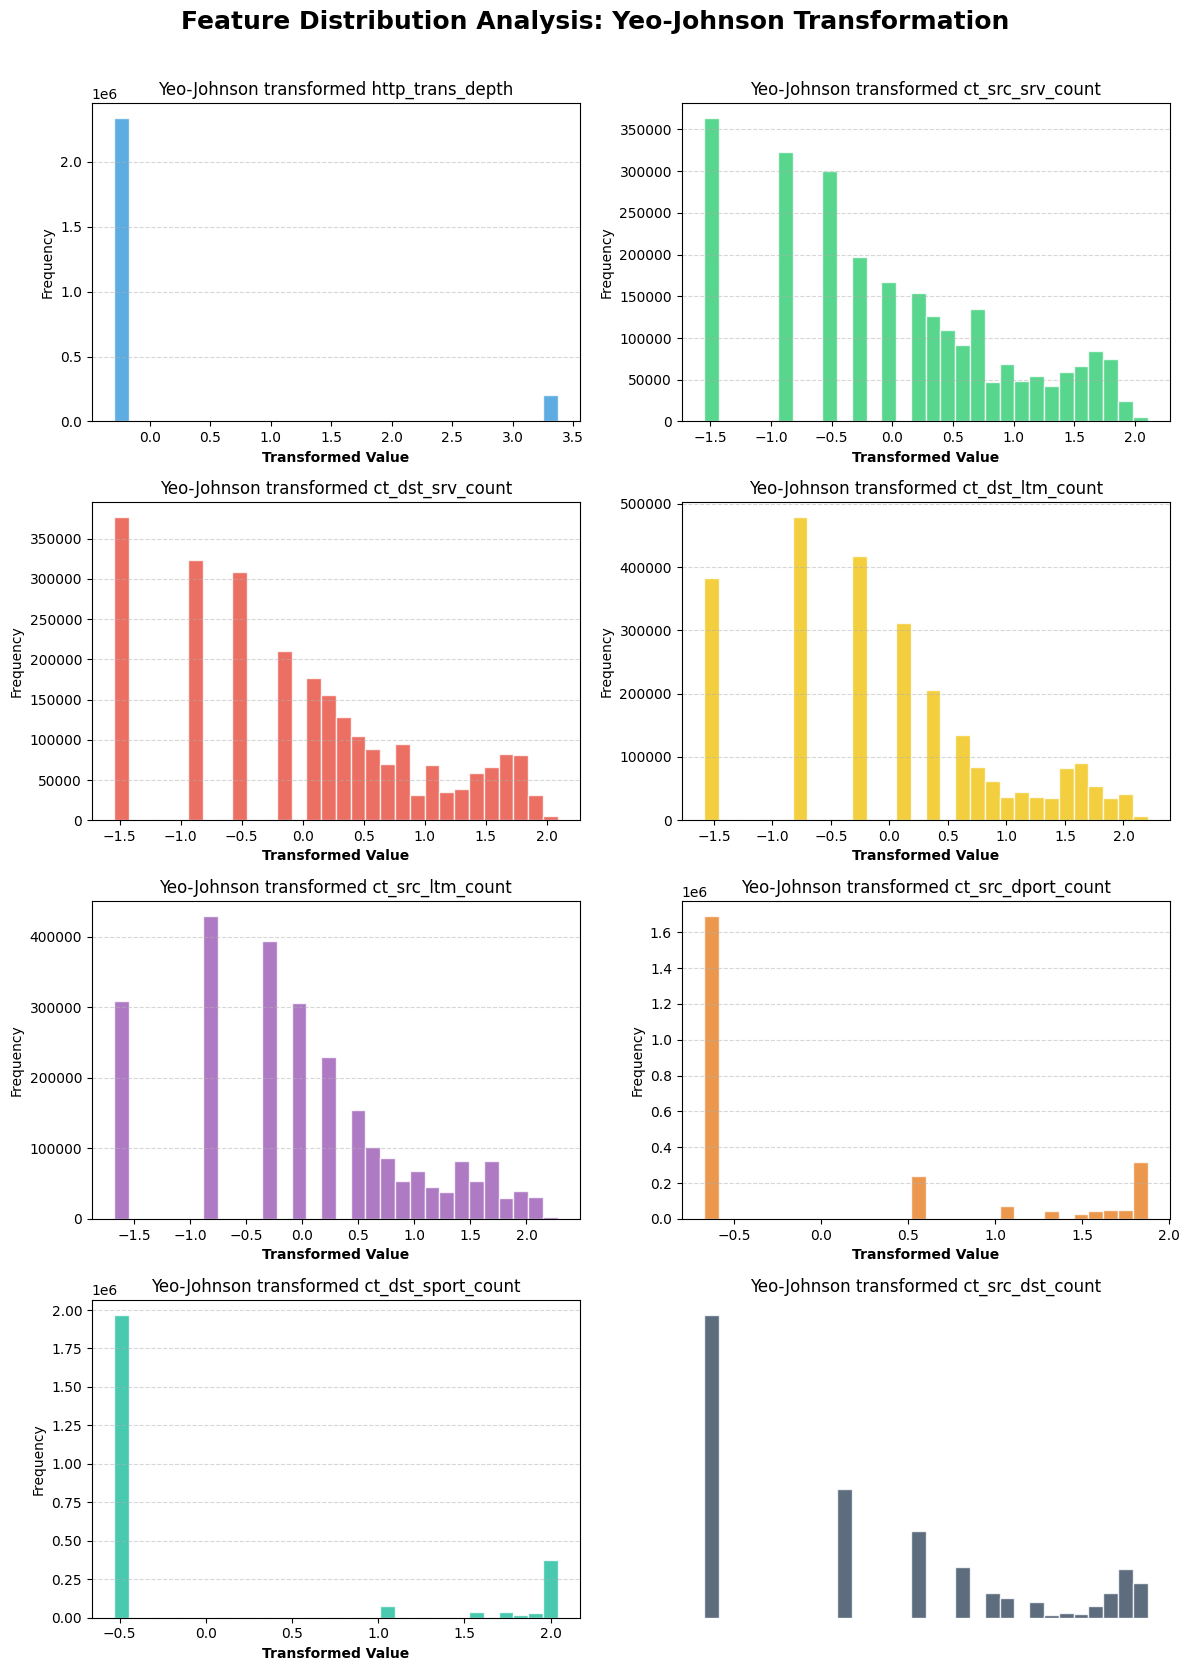

76522

In [29]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson', standardize=True)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 17))
fig.suptitle('Feature Distribution Analysis: Yeo-Johnson Transformation', fontsize=18, fontweight='bold')
axes = axes.flatten()

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6', 
          '#e67e22', '#1abc9c', '#34495e', '#d35400']

for i, feature in enumerate(feature_list3):
    data_clean = df_combined[feature].dropna().values.reshape(-1, 1)
    transformed_data = pt.fit_transform(data_clean)
    
    axes[i].hist(transformed_data, bins=30, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Yeo-Johnson transformed {feature}', fontsize=12)
    axes[i].set_xlabel('Transformed Value', fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

axes[-1].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
del data_clean
del pt
del transformed_data
gc.collect()

### **4**
### **'dst_load_bps','tcp_rtt','duration','dst_inter_packet_time','src_inter_packet_time','src_jitter','src_load_bps','tcp_synack_time','dst_jitter'**

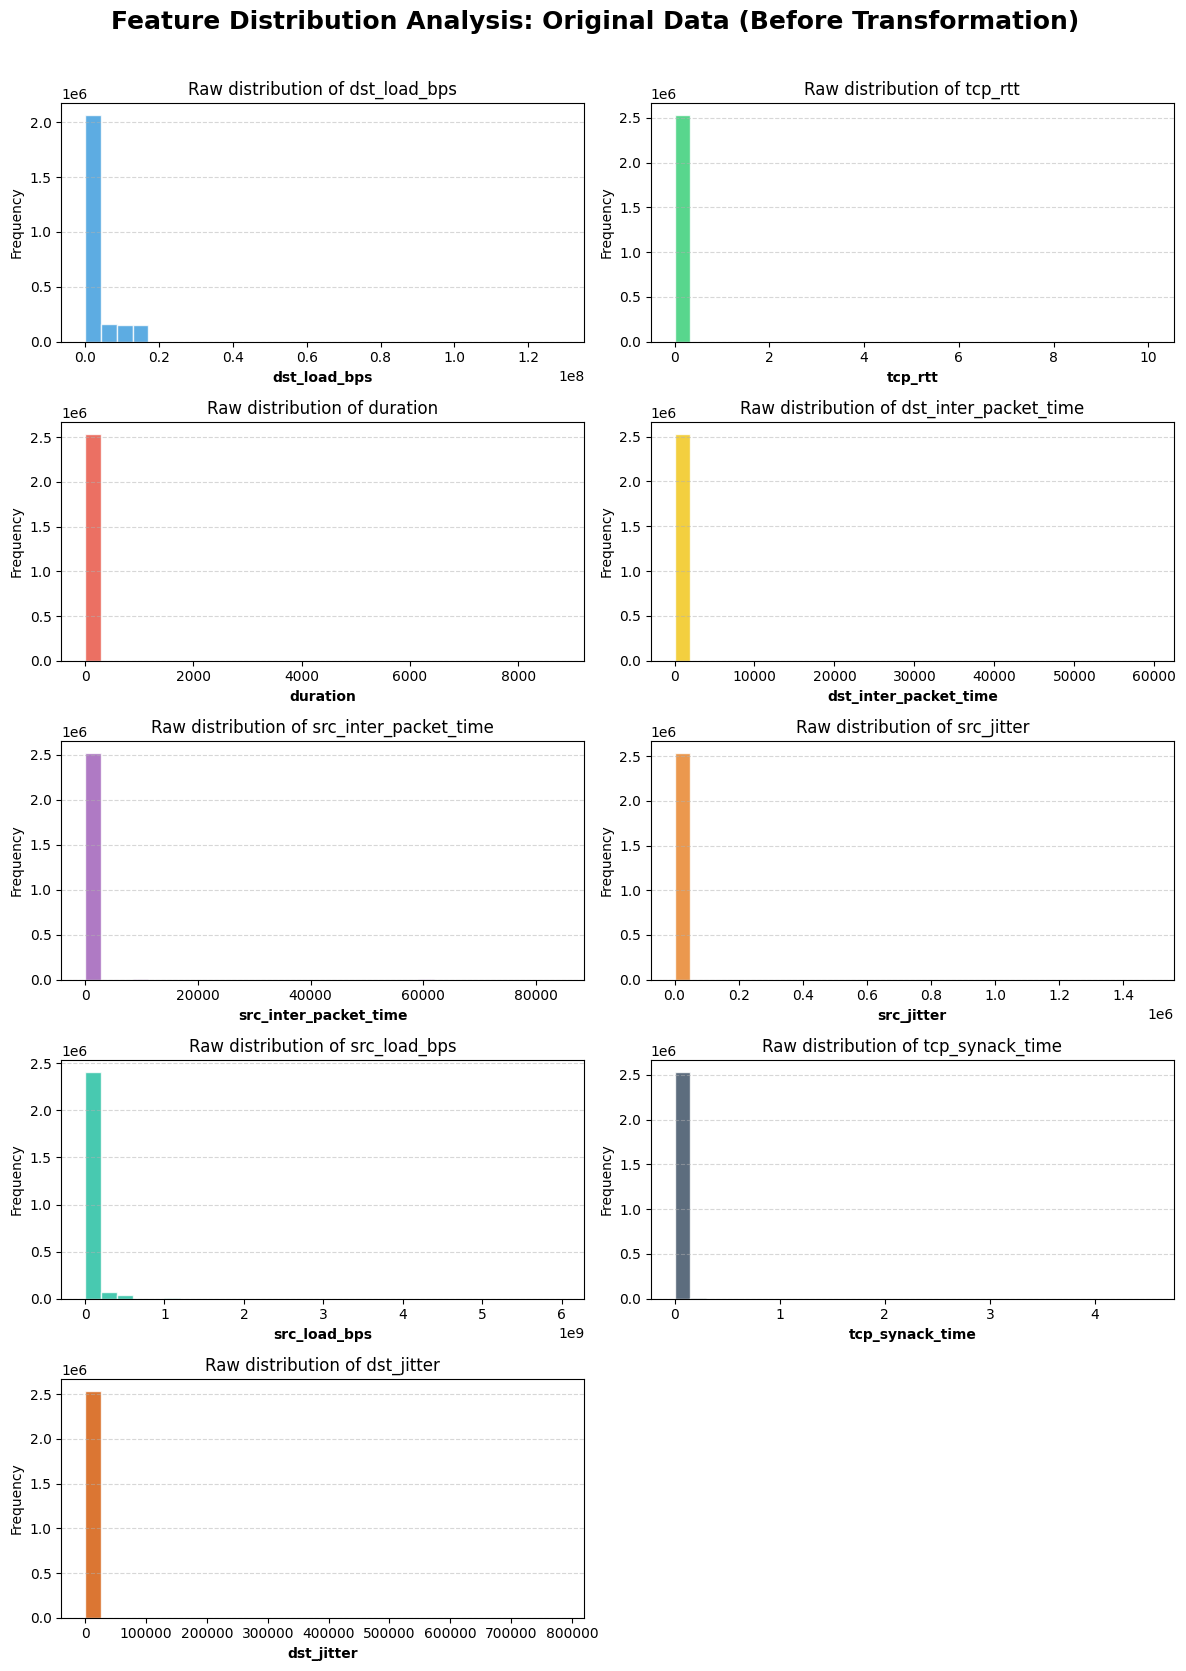

In [30]:
feature_list4 = ['dst_load_bps','tcp_rtt','duration','dst_inter_packet_time','src_inter_packet_time','src_jitter','src_load_bps','tcp_synack_time','dst_jitter']
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 17))
fig.suptitle('Feature Distribution Analysis: Original Data (Before Transformation)', fontsize=18, fontweight='bold')
axes = axes.flatten()

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6', 
          '#e67e22', '#1abc9c', '#34495e', '#d35400']

for i, feature in enumerate(feature_list4):
    axes[i].hist(df_combined[feature].dropna(), bins=30, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Raw distribution of {feature}', fontsize=12)
    axes[i].set_xlabel(feature, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

axes[-1].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

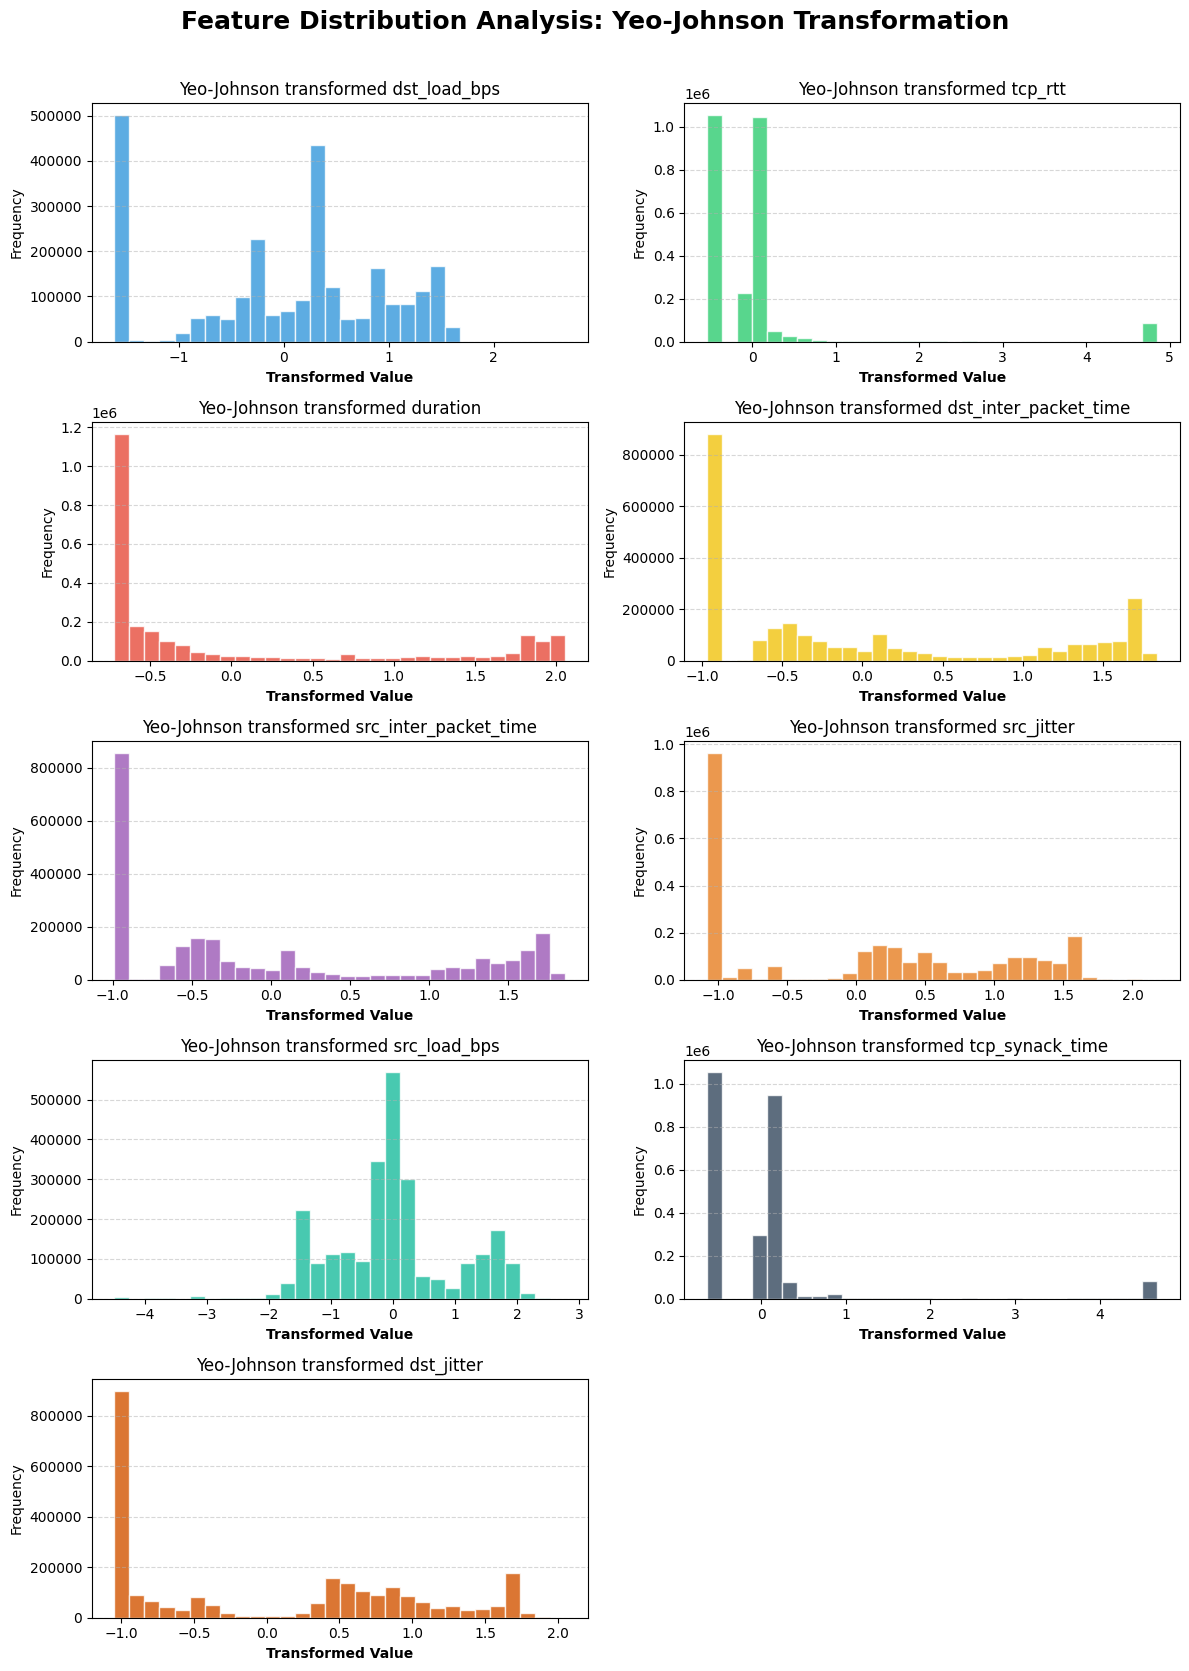

76238

In [31]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson', standardize=True)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 17))
fig.suptitle('Feature Distribution Analysis: Yeo-Johnson Transformation', fontsize=18, fontweight='bold')
axes = axes.flatten()

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6', 
          '#e67e22', '#1abc9c', '#34495e', '#d35400']

for i, feature in enumerate(feature_list4):
    data_clean = df_combined[feature].dropna().values.reshape(-1, 1)
    transformed_data = pt.fit_transform(data_clean)
    
    axes[i].hist(transformed_data, bins=30, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Yeo-Johnson transformed {feature}', fontsize=12)
    axes[i].set_xlabel('Transformed Value', fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

axes[-1].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
del data_clean
del pt
del transformed_data
gc.collect()

In [32]:
df_combined.isna().sum()

src_ip                   0
src_port                 0
dst_ip                   0
dst_port                 0
protocol                 0
conn_state               0
duration                 0
src_to_dst_bytes         0
dst_to_src_bytes         0
src_ttl                  0
dst_ttl                  0
src_loss                 0
dst_loss                 0
service_type             0
src_load_bps             0
dst_load_bps             0
src_packet_count         0
dst_packet_count         0
src_window_adv           0
dst_window_adv           0
src_tcp_seq              0
dst_tcp_seq              0
src_mean_packet_size     0
dst_mean_packet_size     0
http_trans_depth         0
http_res_body_len        0
src_jitter               0
dst_jitter               0
start_time               0
last_time                0
src_inter_packet_time    0
dst_inter_packet_time    0
tcp_rtt                  0
tcp_synack_time          0
tcp_ackdat_time          0
is_same_ip_port          0
ct_src_srv_count         0
c

In [33]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2540047 entries, 0 to 2540046
Data columns (total 49 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   src_ip                 object 
 1   src_port               int64  
 2   dst_ip                 object 
 3   dst_port               int64  
 4   protocol               object 
 5   conn_state             object 
 6   duration               float64
 7   src_to_dst_bytes       int64  
 8   dst_to_src_bytes       int64  
 9   src_ttl                int64  
 10  dst_ttl                int64  
 11  src_loss               int64  
 12  dst_loss               int64  
 13  service_type           object 
 14  src_load_bps           float64
 15  dst_load_bps           float64
 16  src_packet_count       int64  
 17  dst_packet_count       int64  
 18  src_window_adv         int64  
 19  dst_window_adv         int64  
 20  src_tcp_seq            int64  
 21  dst_tcp_seq            int64  
 22  src_mean_packet_si

### Feature Selection Reasoning

After doing some research on what these columns actually mean in network traffic, I decided to drop them because they do not help our machine learning model detect attacks. Here is the simple breakdown:

1. src_tcp_seq and dst_tcp_seq
These are just random, giant numbers (up to billions) generated by computers to keep track of the order of data sent over TCP. They change completely every time a new connection happens. Also, the 35% of zeros here just means the connection used UDP or ARP, which do not use these sequence numbers. Because these numbers are purely random and temporary, they are just "noise" that will confuse our Autoencoder. 

2. src_ip and dst_ip
These are the IP addresses of the sender and receiver. If we keep them, the model will just memorize which specific computer was attacked in the past. We want our model to learn "how an attack behaves," not "which IP address was targeted."

3. start_time and last_time
These are timestamps showing exactly when the network activity started and ended. Cyberattacks can happen at any second, day, or year. Raw timestamps are too specific and do not contain general patterns for anomaly detection.

4. src_port and dst_port
These are port numbers (like port 80 for web browsing, etc.). While some ports are commonly targeted, raw port numbers can cause overfitting because the model might blindly flag any traffic on a certain port as malicious, missing the actual behavioral patterns.

In short, we drop all these columns to clean up the dataset and force the Autoencoder to focus purely on the behavioral characteristics of the network traffic.

In [34]:
cols_to_drop = [
    'src_ip', 'dst_ip','start_time', 'last_time','src_port', 'dst_port','src_tcp_seq','dst_tcp_seq'
]
df_combined = df_combined.drop(columns=cols_to_drop)

### **Splitting Data for Isolation Forest Model**

In [35]:
data_normal = df_combined[df_combined['label']==0]
data_not_normal = df_combined[df_combined['label']==1]
data_train, data_train2 = train_test_split(data_normal, test_size=0.15, random_state=42)
data_train.drop(columns=['attack_category','label'],axis=1,inplace=True)
data_test = pd.concat([data_train2,data_not_normal],axis=0)
data_test.to_csv('test_data.csv',index=False)
ground_truth = data_test['label'].copy()
data_test.drop(columns=['attack_category','label'],axis=1,inplace=True)

In [36]:
for item in data_train.columns:
    print(data_train[item].value_counts(normalize=True)*100)
    print()

protocol
tcp     64.758432
udp     34.554487
arp      0.454254
ospf     0.204194
icmp     0.024550
igmp     0.003287
udt      0.000424
rtp      0.000318
esp      0.000053
Name: proportion, dtype: float64

conn_state
FIN    64.037999
CON    25.192993
INT    10.360938
REQ     0.351123
RST     0.023436
ECO     0.015589
CLO     0.007158
URH     0.005196
ACC     0.001803
PAR     0.001326
TST     0.000477
ECR     0.000477
no      0.000424
URN     0.000424
MAS     0.000318
TXD     0.000318
Name: proportion, dtype: float64

duration
0.000007     2.069038
0.000009     1.369549
0.000002     1.299452
0.000003     1.219227
0.000008     1.162121
               ...   
34.375160    0.000053
0.876795     0.000053
0.488781     0.000053
7.148899     0.000053
0.250883     0.000053
Name: proportion, Length: 487158, dtype: float64

src_to_dst_bytes
146      11.678312
264       9.634990
130       4.260402
1684      3.982186
568       3.759646
           ...    
31896     0.000053
11516     0.000053
22272   

In [37]:
data_train.select_dtypes('object')

,protocol,conn_state,service_type
2353461,tcp,FIN,unknown
1589399,tcp,FIN,ftp
1195246,tcp,FIN,unknown
2033836,udp,CON,dns
418497,tcp,FIN,unknown
...,...,...,...
2273127,tcp,FIN,unknown
1729890,tcp,FIN,unknown
754395,tcp,FIN,http
125173,tcp,FIN,smtp


In [38]:
transformer = PowerTransformer(method='yeo-johnson', standardize=True)
scaler = MinMaxScaler()
oh_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [39]:
# Fit & Transform pada data_train
categorical_features = data_train.select_dtypes("object").columns
df_transformed = data_train.copy()
df_transformed[feature_list1+feature_list3+feature_list4] = transformer.fit_transform(df_transformed[feature_list1+feature_list3+feature_list4])
df_transformed[feature_list2] = scaler.fit_transform(df_transformed[feature_list2])
encoded_array = oh_encoder.fit_transform(df_transformed[categorical_features])
new_col_names = oh_encoder.get_feature_names_out(categorical_features)
df_encoded_cols = pd.DataFrame(encoded_array, columns=new_col_names, index=df_transformed.index)
df_transformed = pd.concat([df_transformed, df_encoded_cols], axis=1)
df_transformed.drop(columns=categorical_features, inplace=True)
df_transformed

,duration,src_to_dst_bytes,dst_to_src_bytes,src_ttl,dst_ttl,src_loss,dst_loss,src_load_bps,dst_load_bps,src_packet_count,...,service_type_ftp,service_type_ftp-data,service_type_http,service_type_irc,service_type_pop3,service_type_radius,service_type_smtp,service_type_snmp,service_type_ssh,service_type_unknown
2353461,0.150900,0.757472,1.184681,0.121569,0.114173,0.742434,1.176325,-0.233292,0.830764,1.111088,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1589399,2.024120,0.566025,0.167390,0.121569,0.114173,1.084530,0.855594,-1.568259,-1.071528,0.940592,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1195246,-0.424834,0.744020,1.174954,0.121569,0.114173,0.742434,1.158325,0.178128,1.472323,1.092316,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2033836,-0.742413,-1.407041,-0.742527,0.121569,0.114173,-1.196087,-1.179783,0.015211,0.070190,-1.263247,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
418497,-0.711068,-0.089487,0.001394,0.121569,0.114173,0.331852,0.121454,0.433408,0.839058,-0.053479,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2273127,-0.482723,0.690947,1.113182,0.121569,0.114173,0.742434,1.099422,0.220628,1.507860,1.032045,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1729890,-0.705522,0.733093,0.028080,0.121569,0.114173,0.742434,0.436452,0.859506,0.832304,0.229867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
754395,1.984417,0.179957,0.517204,0.121569,0.114173,0.131488,0.246774,-1.637950,-0.775002,-0.053479,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
125173,1.891127,2.051547,0.143428,0.121569,0.114173,1.500129,0.511359,-0.290593,-0.902805,0.964822,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [40]:
# Transform pada data_test
df_test_transformed = data_test.copy()
df_test_transformed[feature_list1+feature_list3+feature_list4] = transformer.transform(df_test_transformed[feature_list1+feature_list3+feature_list4])
df_test_transformed[feature_list2] = scaler.transform(df_test_transformed[feature_list2])
encoded_array_test = oh_encoder.transform(df_test_transformed[categorical_features])
df_encoded_cols_test = pd.DataFrame(encoded_array_test, columns=new_col_names, index=df_test_transformed.index)
df_test_transformed = pd.concat([df_test_transformed, df_encoded_cols_test], axis=1)
df_test_transformed.drop(columns=categorical_features, inplace=True)
df_test_transformed

,duration,src_to_dst_bytes,dst_to_src_bytes,src_ttl,dst_ttl,src_loss,dst_loss,src_load_bps,dst_load_bps,src_packet_count,...,service_type_ftp,service_type_ftp-data,service_type_http,service_type_irc,service_type_pop3,service_type_radius,service_type_smtp,service_type_snmp,service_type_ssh,service_type_unknown
1557915,-0.742641,-1.477726,-0.764038,0.121569,0.114173,-1.196087,-1.179783,-0.012881,0.047868,-1.263247,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1840217,1.938662,2.042428,0.122889,0.121569,0.114173,1.459155,0.511359,-0.363404,-0.953499,0.940592,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1733530,-0.708586,-0.481942,-0.591157,0.121569,0.114173,-1.196087,-1.179783,0.129692,-0.100148,-0.820073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
304056,0.559792,0.218715,0.086574,0.121569,0.114173,0.331852,-0.037548,-0.749533,-0.504953,0.229867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1323236,-0.171826,-0.866307,-0.061374,0.121569,0.114173,-0.514033,-0.252051,-1.012860,-0.348290,-0.541132,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540027,-0.752993,-1.581001,-1.871481,0.996078,0.000000,-1.196087,-1.179783,2.333059,-1.899398,-1.263247,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2540028,1.778648,-0.474991,-0.370960,0.243137,0.992126,0.492945,0.349614,-1.733473,-1.161709,-0.053479,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2540029,2.009985,3.081976,-0.173795,0.243137,0.992126,2.732016,-0.573586,0.163604,-1.209485,1.776927,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2540030,2.009985,3.081976,-0.173795,0.243137,0.992126,2.732016,-0.573586,0.163604,-1.209485,1.776927,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Model

In [41]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42, n_jobs=-1)
iso_forest.fit(df_transformed)

IsolationForest(contamination=0.1, n_jobs=-1, random_state=42)

In [42]:
test_preds = iso_forest.predict(df_test_transformed)
y_pred = [1 if p == -1 else 0 for p in test_preds]
print("========== ISOLATION FOREST PERFORMANCE ==========")
print(classification_report(ground_truth, y_pred, target_names=['Normal', 'Anomaly/Attack']))

========== ISOLATION FOREST PERFORMANCE ==========
                precision    recall  f1-score   support

        Normal       1.00      0.90      0.95    332815
Anomaly/Attack       0.91      1.00      0.95    321283

      accuracy                           0.95    654098
     macro avg       0.95      0.95      0.95    654098
  weighted avg       0.95      0.95      0.95    654098



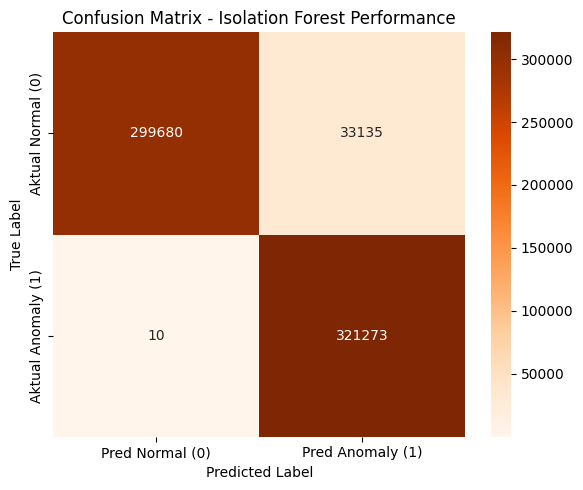

In [43]:
cm = confusion_matrix(ground_truth, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Pred Normal (0)', 'Pred Anomaly (1)'], 
            yticklabels=['Aktual Normal (0)', 'Aktual Anomaly (1)'])

plt.title('Confusion Matrix - Isolation Forest Performance')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [44]:
mlflow.set_experiment("Network_Anomaly_Detection-Isolation_Forest")
with mlflow.start_run(run_name="Isolation_forest_Model"):
    n_estimators = 100
    contamination = 0.1
    random_state = 42

    mlflow.log_param("Model_Name", "Isolation_Forest")
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("contamination", 0.1)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("Model_Name", "Isolation_Forest")
    model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42, n_jobs=-1)
    model.fit(df_transformed)

    test_preds = model.predict(df_test_transformed)
    y_pred = [1 if p == -1 else 0 for p in test_preds]

    precission_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
        ground_truth, y_pred, average=None
    )

    mlflow.log_metric("Precission_Normal_Class", precission_per_class[0])
    mlflow.log_metric("Recall_Normal_Class", recall_per_class[0])
    mlflow.log_metric("F1_Score_Normal_Class", f1_per_class[0])
    mlflow.log_metric("Precission_Anomaly_Class", precission_per_class[1])
    mlflow.log_metric("Recall_Anomaly_Class", recall_per_class[1])
    mlflow.log_metric("F1_Score_Anomaly_Class", f1_per_class[1])

    print(f"[Normal] Class   -> F1: {f1_per_class[0]:.4f} | Recall: {recall_per_class[0]:.4f}")
    print(f"[Anomaly] Class -> F1: {f1_per_class[1]:.4f} | Recall: {recall_per_class[1]:.4f}\n")

    cm = confusion_matrix(ground_truth, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=['Pred Normal (0)', 'Pred Anomaly (1)'], 
                yticklabels=['Aktual Normal (0)', 'Aktual Anomaly (1)'])
    plt.title('Confusion Matrix - Isolation Forest')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plot_path = 'confusion_matrix.png'
    plt.savefig(plot_path)
    plt.close()

    
    mlflow.log_artifact(plot_path)
    joblib.dump(transformer, 'power_transformer_yj.pkl')
    joblib.dump(scaler, 'minmax_scaler.pkl')
    joblib.dump(oh_encoder, 'one_hot_encoder.pkl')

    mlflow.log_artifact('power_transformer_yj.pkl', artifact_path='Preprocessing_Pickles')
    mlflow.log_artifact('minmax_scaler.pkl', artifact_path='Preprocessing_Pickles')
    mlflow.log_artifact('one_hot_encoder.pkl', artifact_path='Preprocessing_Pickles')

    os.remove('power_transformer_yj.pkl')
    os.remove('minmax_scaler.pkl')
    os.remove('one_hot_encoder.pkl')
    
    mlflow.sklearn.log_model(model, artifact_path='ISO_Model')
    print("Done")
    

2026/06/14 19:40:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/14 19:40:43 INFO mlflow.store.db.utils: Updating database tables
2026/06/14 19:40:44 INFO mlflow.tracking.fluent: Experiment with name 'Network_Anomaly_Detection-Isolation_Forest' does not exist. Creating a new experiment.


[Normal] Class   -> F1: 0.9476 | Recall: 0.9004
[Anomaly] Class -> F1: 0.9509 | Recall: 1.0000



2026/06/14 19:40:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 19:40:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Done


In [45]:
data3.iloc[:100].to_csv("raw_data.csv",index=False)

In [46]:
joblib.dump(transformer, 'power_transformer_yj.pkl')
joblib.dump(scaler, 'minmax_scaler.pkl')
joblib.dump(oh_encoder, 'one_hot_encoder.pkl')

['one_hot_encoder.pkl']

In [47]:
!zip -r mlruns.zip mlruns

  adding: mlruns/ (stored 0%)
  adding: mlruns/1/ (stored 0%)
  adding: mlruns/1/models/ (stored 0%)
  adding: mlruns/1/models/m-5668ac66e7674d72871bd0eb8c67a487/ (stored 0%)
  adding: mlruns/1/models/m-5668ac66e7674d72871bd0eb8c67a487/artifacts/ (stored 0%)
  adding: mlruns/1/models/m-5668ac66e7674d72871bd0eb8c67a487/artifacts/requirements.txt (deflated 17%)
  adding: mlruns/1/models/m-5668ac66e7674d72871bd0eb8c67a487/artifacts/python_env.yaml (deflated 16%)
  adding: mlruns/1/models/m-5668ac66e7674d72871bd0eb8c67a487/artifacts/model.pkl (deflated 74%)
  adding: mlruns/1/models/m-5668ac66e7674d72871bd0eb8c67a487/artifacts/MLmodel (deflated 48%)
  adding: mlruns/1/models/m-5668ac66e7674d72871bd0eb8c67a487/artifacts/conda.yaml (deflated 32%)
  adding: mlruns/1/47382dd4a5d149d0b2bdb4c3976c1288/ (stored 0%)
  adding: mlruns/1/47382dd4a5d149d0b2bdb4c3976c1288/artifacts/ (stored 0%)
  adding: mlruns/1/47382dd4a5d149d0b2bdb4c3976c1288/artifacts/Preprocessing_Pickles/ (stored 0%)
  adding: ml